In [ ]:
# Install packages
!pip install huggingface_hub
!pip install datasets
!pip install evaluate
!pip install bert_score
!pip install rouge_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which 

In [ ]:
# Import necessary modules
from torch import Tensor
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel
from datasets import load_dataset
from copy import deepcopy
from tqdm import tqdm
from peft import PeftModel, PeftConfig
import matplotlib.pyplot as plt
import torch.nn.functional as F
import evaluate
import torch
import re
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Use the token to log in
from huggingface_hub import login
login("")

In [ ]:
# Load Models

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
tokenizer.pad_token = tokenizer.eos_token

# Base Llama Model
base_model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B").to(device)

# Layerskip Model
# layerskip_tokenizer = AutoTokenizer.from_pretrained("facebook/layerskip-llama3.2-1B")
layerskip_model = AutoModelForCausalLM.from_pretrained("facebook/layerskip-llama3.2-1B").to(device)
layerskip_layers = layerskip_model.model.layers

# # Fine-tuned model
finetuned_layerskip_model = AutoModelForCausalLM.from_pretrained("HassaanSeeker/Llama-3.2-1b-hf-layerskip-v1-finetuned").to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/864 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

In [ ]:
finetuned_layerskip_model= finetuned_model

In [ ]:
# Load ROUGE metric
rouge = evaluate.load("rouge")
bert = evaluate.load("bertscore")
perplexity = evaluate.load("perplexity", module_type="metric")

In [ ]:
wiki_dataset = load_dataset("wikitext", "wikitext-103-raw-v1")
train_dataset = wiki_dataset['train']
test_dataset = wiki_dataset['test']
validation_dataset = wiki_dataset['validation']

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/733k [00:00<?, ?B/s]

train-00000-of-00002.parquet:   0%|          | 0.00/157M [00:00<?, ?B/s]

train-00001-of-00002.parquet:   0%|          | 0.00/157M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset[0]['text'])
print()
print(train_dataset[1]['text'])
print()
print(train_dataset[2]['text'])
print()
print(train_dataset[3]['text'])
print()
print(train_dataset[4]['text'])



 = Valkyria Chronicles III = 




 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . 


 The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for ser

In [ ]:
tokenized_test_dataset = tokenizer(test_dataset['text'], truncation=True, padding=True)

In [ ]:
def evaluate_next_token_predictions(text, model, tokenizer, max_len=128):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len)
    input_ids = tokens.input_ids.to(model.device)

    # Shift input to predict next token at each step
    logits = model(input_ids).logits  # shape: [1, seq_len, vocab_size]
    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]

    # Cross-entropy loss (avg over tokens)
    loss = F.cross_entropy(shift_logits.reshape(-1, shift_logits.size(-1)), shift_labels.reshape(-1), reduction="mean")

    # Token-wise prediction accuracy
    preds = shift_logits.argmax(dim=-1)
    accuracy = (preds == shift_labels).float().mean().item()

    return loss.item(), accuracy

In [ ]:
# # Model Performance Comparison (No Layerskip)
# models = {"base model": base_model, "finetuned model":finetuned_model, "layerskip model": layerskip_model}
# for model_name in models.keys():
#   model = models[model_name]  # your logic to load them
#   total_loss, total_acc = 0, 0
#   count = 0

#   for example in test_dataset.select(range(500)):
#     text = example["text"].strip()
#     if not text:
#       continue
#     loss, acc = evaluate_next_token_predictions(text, model, tokenizer)
#     total_loss += loss
#     total_acc += acc
#     count += 1

#   avg_loss = total_loss / count
#   avg_ppl = torch.exp(torch.tensor(avg_loss)).item()
#   avg_acc = total_acc / count

#   print(f"{model_name} — Loss: {avg_loss:.4f}, PPL: {avg_ppl:.2f}, Accuracy: {avg_acc:.4f}")

In [ ]:
models = {"base LLaMA model": base_model, "finetuned LLaMA model": finetuned_model, "base LayerSkip model": layerskip_model}
# Store all results here
early_exit_metrics = {
    "base LLaMA model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "finetuned LLaMA model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "base LayerSkip model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}")
    original_layers = model.model.layers  # Save full depth

    for i in range(len(original_layers)):
        model.model.layers = original_layers[:i + 1]  # Simulate early exit at i+1

        total_loss, total_acc, count = 0.0, 0.0, 0

        for example in test_dataset.select(range(1000)):
            text = example["text"].strip()
            if not text:
                continue
            try:
                loss, acc = evaluate_next_token_predictions(text, model, tokenizer)
                total_loss += loss
                total_acc += acc
                count += 1
            except Exception as e:
                print(f"[!] Skipping due to error: {e}")
                continue

        if count == 0:
            continue

        avg_loss = total_loss / count
        avg_ppl = torch.exp(torch.tensor(avg_loss)).item()
        avg_acc = total_acc / count

        # Store results
        early_exit_metrics[model_name]["layers"].append(i + 1)
        early_exit_metrics[model_name]["loss"].append(avg_loss)
        early_exit_metrics[model_name]["accuracy"].append(avg_acc)
        early_exit_metrics[model_name]["perplexity"].append(avg_ppl)

        print(f"[{model_name}] Layer {i+1} — Loss: {avg_loss:.4f}, PPL: {avg_ppl:.2f}, Acc: {avg_acc:.4f}")

    # Restore full layers after testing
    model.model.layers = original_layers


Evaluating base LLaMA model
[base LLaMA model] Layer 1 — Loss: 30.9196, PPL: 26804066713600.00, Acc: 0.0499
[base LLaMA model] Layer 2 — Loss: 19.7175, PPL: 365754208.00, Acc: 0.0381
[base LLaMA model] Layer 3 — Loss: 15.8691, PPL: 7795615.00, Acc: 0.0002
[base LLaMA model] Layer 4 — Loss: 13.7745, PPL: 959825.31, Acc: 0.0005
[base LLaMA model] Layer 5 — Loss: 12.8624, PPL: 385524.12, Acc: 0.0012
[base LLaMA model] Layer 6 — Loss: 12.8151, PPL: 367745.88, Acc: 0.0017
[base LLaMA model] Layer 7 — Loss: 12.9480, PPL: 419997.78, Acc: 0.0018
[base LLaMA model] Layer 8 — Loss: 12.9700, PPL: 429346.00, Acc: 0.0022
[base LLaMA model] Layer 9 — Loss: 13.1679, PPL: 523271.75, Acc: 0.0037
[base LLaMA model] Layer 10 — Loss: 12.1239, PPL: 184227.05, Acc: 0.0130
[base LLaMA model] Layer 11 — Loss: 11.2979, PPL: 80651.65, Acc: 0.0309
[base LLaMA model] Layer 12 — Loss: 10.5305, PPL: 37439.60, Acc: 0.0620
[base LLaMA model] Layer 13 — Loss: 9.5095, PPL: 13487.53, Acc: 0.0939
[base LLaMA model] Laye

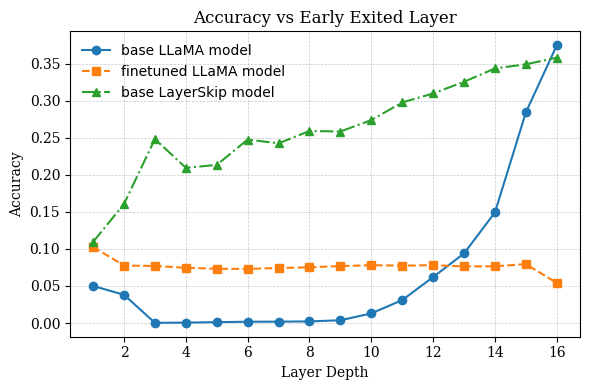

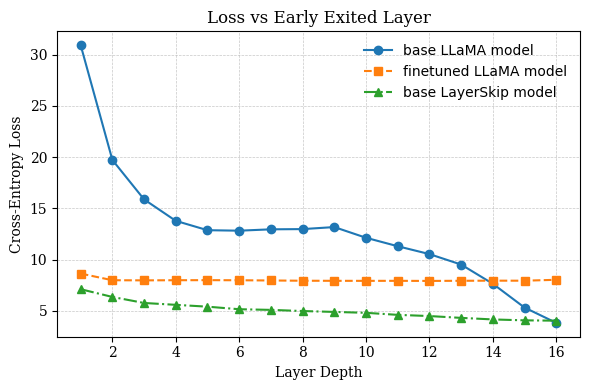

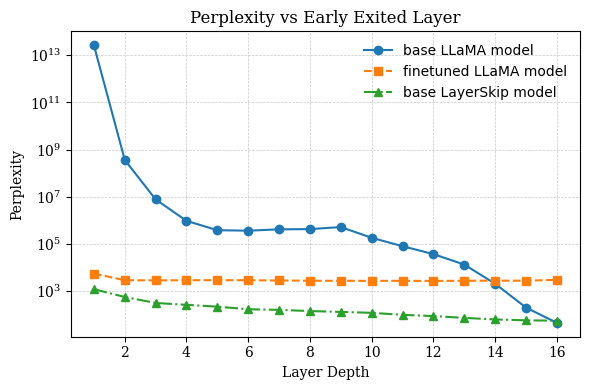

In [ ]:
def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(6, 4), dpi=100)
    markers = ['o', 's', '^', 'D', '*', 'x']
    linestyles = ['-', '--', '-.', ':']

    for idx, model_name in enumerate(early_exit_metrics):
        plt.plot(early_exit_metrics[model_name]["layers"],
                 early_exit_metrics[model_name][metric_name],
                 marker=markers[idx % len(markers)],
                 linestyle=linestyles[idx % len(linestyles)],
                 label=model_name)

    plt.title(f"{metric_name.replace('_', ' ').title()} vs Early Exited Layer", fontname="serif")
    plt.xlabel("Layer Depth", fontname="serif")
    plt.ylabel(ylabel, fontname="serif")
    plt.xticks(fontname="serif")
    plt.yticks(fontname="serif")

    if metric_name == "perplexity":
        plt.yscale('log')  # ✨ Log scale for perplexity ✨

    plt.legend(loc='best', frameon=False)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot all 3 metrics
plot_metric("accuracy", "Accuracy")
plot_metric("loss", "Cross-Entropy Loss")
plot_metric("perplexity", "Perplexity")

In [ ]:
models = {"base LLaMA model": base_model, "finetuned LLaMA model": finetuned_model, "base LayerSkip model": layerskip_model}
# Store all results here
skip_layer_metrics = {
    "base LLaMA model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "finetuned LLaMA model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "base LayerSkip model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}")
    original_layers = model.model.layers  # Save full depth

    for i in range(len(original_layers)):
        model.model.layers = original_layers[:i] + original_layers[i + 1:]  # Simulate early exit at i+1

        total_loss, total_acc, count = 0.0, 0.0, 0

        for example in test_dataset.select(range(1000)):
            text = example["text"].strip()
            if not text:
                continue
            try:
                loss, acc = evaluate_next_token_predictions(text, model, tokenizer)
                total_loss += loss
                total_acc += acc
                count += 1
            except Exception as e:
                print(f"[!] Skipping due to error: {e}")
                continue

        if count == 0:
            continue

        avg_loss = total_loss / count
        avg_ppl = torch.exp(torch.tensor(avg_loss)).item()
        avg_acc = total_acc / count

        # Store results
        skip_layer_metrics[model_name]["layers"].append(i + 1)
        skip_layer_metrics[model_name]["loss"].append(avg_loss)
        skip_layer_metrics[model_name]["accuracy"].append(avg_acc)
        skip_layer_metrics[model_name]["perplexity"].append(avg_ppl)

        print(f"[{model_name}] Layer {i+1} — Loss: {avg_loss:.4f}, PPL: {avg_ppl:.2f}, Acc: {avg_acc:.4f}")

    # Restore full layers after testing
    model.model.layers = original_layers


Evaluating base LLaMA model
[base LLaMA model] Layer 1 — Loss: 10.8025, PPL: 49141.06, Acc: 0.0051
[base LLaMA model] Layer 2 — Loss: 8.1077, PPL: 3319.88, Acc: 0.1142
[base LLaMA model] Layer 3 — Loss: 4.5237, PPL: 92.17, Acc: 0.3050
[base LLaMA model] Layer 4 — Loss: 4.4755, PPL: 87.83, Acc: 0.3050
[base LLaMA model] Layer 5 — Loss: 4.3219, PPL: 75.33, Acc: 0.3295
[base LLaMA model] Layer 6 — Loss: 4.1587, PPL: 63.99, Acc: 0.3365
[base LLaMA model] Layer 7 — Loss: 3.9702, PPL: 53.00, Acc: 0.3562
[base LLaMA model] Layer 8 — Loss: 4.0719, PPL: 58.67, Acc: 0.3491
[base LLaMA model] Layer 9 — Loss: 4.1263, PPL: 61.95, Acc: 0.3320
[base LLaMA model] Layer 10 — Loss: 4.4226, PPL: 83.32, Acc: 0.3046
[base LLaMA model] Layer 11 — Loss: 4.2904, PPL: 72.99, Acc: 0.3125
[base LLaMA model] Layer 12 — Loss: 4.3856, PPL: 80.28, Acc: 0.3011
[base LLaMA model] Layer 13 — Loss: 4.1585, PPL: 63.98, Acc: 0.3277
[base LLaMA model] Layer 14 — Loss: 4.4052, PPL: 81.87, Acc: 0.2985
[base LLaMA model] Lay

In [ ]:
def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(6, 4), dpi=100)
    markers = ['o', 's', '^', 'D', '*', 'x']
    linestyles = ['-', '--', '-.', ':']

    for idx, model_name in enumerate(skip_layer_metrics):
        plt.plot(skip_layer_metrics[model_name]["layers"],
                 skip_layer_metrics[model_name][metric_name],
                 marker=markers[idx % len(markers)],
                 linestyle=linestyles[idx % len(linestyles)],
                 label=model_name)

    plt.title(f"{metric_name.replace('_', ' ').title()} vs Number of Skipped Layers", fontname="serif")
    plt.xlabel("Layer Depth", fontname="serif")
    plt.ylabel(ylabel, fontname="serif")
    plt.xticks(fontname="serif")
    plt.yticks(fontname="serif")

    if metric_name == "perplexity":
        plt.yscale('log')  # ✨ Log scale for perplexity ✨

    plt.legend(loc='best', frameon=False)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot all 3 metrics
plot_metric("accuracy", "Accuracy")
plot_metric("loss", "Cross-Entropy Loss")
plot_metric("perplexity", "Perplexity")

In [ ]:
models = {"base model": base_model, "finetuned model": finetuned_model, "layerskip model": layerskip_model}
# Store all results here
all_metrics = {
    "base model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "finetuned model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "layerskip model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}")
    original_layers = model.model.layers  # Save full depth

    for i in range(len(original_layers)):
        model.model.layers = original_layers[:i + 1]  # Simulate early exit at i+1

        total_loss, total_acc, count = 0.0, 0.0, 0

        for example in test_dataset.select(range(1000)):
            text = example["text"].strip()
            if not text:
                continue
            try:
                loss, acc = evaluate_next_token_predictions(text, model, tokenizer)
                total_loss += loss
                total_acc += acc
                count += 1
            except Exception as e:
                print(f"[!] Skipping due to error: {e}")
                continue

        if count == 0:
            continue

        avg_loss = total_loss / count
        avg_ppl = torch.exp(torch.tensor(avg_loss)).item()
        avg_acc = total_acc / count

        # Store results
        all_metrics[model_name]["layers"].append(i + 1)
        all_metrics[model_name]["loss"].append(avg_loss)
        all_metrics[model_name]["accuracy"].append(avg_acc)
        all_metrics[model_name]["perplexity"].append(avg_ppl)

        print(f"[{model_name}] Layer {i+1} — Loss: {avg_loss:.4f}, PPL: {avg_ppl:.2f}, Acc: {avg_acc:.4f}")

    # Restore full layers after testing
    model.model.layers = original_layers

In [ ]:
temp_all_metrics = deepcopy(all_metrics)
temp_all_metrics["finetuned model"]["perplexity"].pop(0)
temp_all_metrics["base model"]["perplexity"].pop(0)
temp_all_metrics["layerskip model"]["perplexity"].pop(0)

In [ ]:
def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(6, 4))
    for model_name in all_metrics:
        plt.plot(all_metrics[model_name]["layers"],
                 all_metrics[model_name][metric_name],
                 marker='o', label=model_name)

    plt.title(f"{metric_name.capitalize()} vs Layer Depth")
    plt.xlabel("Layer Depth")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot all 3 metrics
plot_metric("accuracy", "Accuracy")
plot_metric("loss", "Cross-Entropy Loss")
plot_metric("perplexity", "Perplexity")

In [ ]:
import torch.nn.functional as F

def evaluate_single_next_token_prediction(text, model, tokenizer, max_len=128, predict_position=-2):
    """
    Evaluate next-token prediction accuracy at a single position in the sequence.

    Args:
        text (str): input text
        model (nn.Module): language model
        tokenizer (Tokenizer): tokenizer
        max_len (int): maximum sequence length
        predict_position (int): which token position to predict (default -2 = second to last token predicts last token)

    Returns:
        loss (float), accuracy (float: 0 or 1)
    """
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len)
    input_ids = tokens.input_ids.to(model.device)

    logits = model(input_ids).logits  # shape: [1, seq_len, vocab_size]

    # Focus only on a single prediction
    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]

    # Select the position we care about
    selected_logit = shift_logits[:, predict_position, :]  # shape: [1, vocab_size]
    selected_label = shift_labels[:, predict_position]     # shape: [1]

    # Loss for this single prediction
    loss = F.cross_entropy(selected_logit, selected_label, reduction="mean")

    # Prediction for this token
    pred = selected_logit.argmax(dim=-1)  # shape: [1]
    accuracy = (pred == selected_label).float().item()

    return loss.item(), accuracy

In [ ]:
models = {"base model": base_model, "finetuned model": finetuned_model, "layerskip model": layerskip_model}
# Store all results here
all_layerskip_metrics = {
    "base model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "finetuned model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "layerskip model": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}")
    original_layers = model.model.layers  # Save full depth

    for i in range(len(original_layers)):
        model.model.layers = original_layers[:i + 1]  # Simulate early exit at i+1

        total_loss, total_acc, count = 0.0, 0.0, 0

        for example in test_dataset.select(range(1000)):
            text = example["text"].strip()
            if not text:
                continue
            try:
                loss, acc = evaluate_single_next_token_prediction(text, model, tokenizer)
                total_loss += loss
                total_acc += acc
                count += 1
            except Exception as e:
                print(f"[!] Skipping due to error: {e}")
                continue

        if count == 0:
            continue

        avg_loss = total_loss / count
        avg_ppl = torch.exp(torch.tensor(avg_loss)).item()
        avg_acc = total_acc / count

        # Store results
        all_layerskip_metrics[model_name]["layers"].append(i + 1)
        all_layerskip_metrics[model_name]["loss"].append(avg_loss)
        all_layerskip_metrics[model_name]["accuracy"].append(avg_acc)
        all_layerskip_metrics[model_name]["perplexity"].append(avg_ppl)

        print(f"[{model_name}] Layer {i+1} — Loss: {avg_loss:.4f}, PPL: {avg_ppl:.2f}, Acc: {avg_acc:.4f}")

    # Restore full layers after testing
    model.model.layers = original_layers

In [ ]:
def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(6, 4))
    for model_name in all_layerskip_metrics:
        plt.plot(all_layerskip_metrics[model_name]["layers"],
                 all_layerskip_metrics[model_name][metric_name],
                 marker='o', label=model_name)

    plt.title(f"{metric_name.capitalize()} vs Layer Depth")
    plt.xlabel("Layer Depth")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot all 3 metrics
plot_metric("accuracy", "Accuracy")
plot_metric("loss", "Cross-Entropy Loss")
plot_metric("perplexity", "Perplexity")